# Regularisation in Machine Learning

```{index} Regularisation
```

Regularisation is a technique designed to prevent models from overfitting. In other words, it helps your model generalise better to unseen data by discouraging it from fitting too closely to the quirks and noise present in your training set. This is typically achieved by adding a penalty term to the model’s cost function, nudging the learning process toward simpler, more robust solutions.

You can think of regularisation like guardrails that keep your model’s complexity in check. By balancing the trade-off between accuracy and generality, regularisation makes your model less likely to latch onto random patterns that don’t translate well to real-world scenarios. Popular approaches to this include L1 (Lasso) and L2 (Ridge) regularisation, both of which incorporate penalty terms that penalize large weight values in slightly different ways.

In practice, you’ll see these techniques widely used in linear models, logistic regression, and even neural networks. Though the math may vary, the principle stays the same: preventing the model from learning too many details that don’t matter in the grand scheme of things. In the end, regularisation is all about striking the right balance to ensure your model delivers consistent and accurate predictions.

 It is also used in large language models (like GPT-4, Claude, DeepSeek, etc.) to help them handle massive amounts of parameters without overfitting to their enormous training corpora. Techniques like dropout, weight decay, and carefully curated training data mitigate the risk of memorizing specific examples rather than truly understanding the underlying language patterns. By incorporating these methods, large language models are more robust, better at generalising, and less likely to produce nonsensical or overly specific responses, especially when confronted with completely new or unusual prompts.

Getting an intuitive understanding of regularisation is easier when you picture how your model’s parameters (or weights) might spiral out of control without it. Consider fitting a curve to a dataset: without regularisation, the model may contort itself excessively to match every data point, resulting in a highly complex, overfitted function that performs well on the training data but poorly on unseen data.

## An example in action

To illustrate regularisation, let's consider a classification problem where the goal is to identify different types of signals, such as sine waves, cosine waves, and square waves. The type of thing you might have seen showing on the screen of an oscilloscope, a signal generator, or an audio waveform.

We pick this example because it is easy to generate significant amounts of synthetic data for this problem. We can create a large number of signals of different types, each with a different frequency, amplitude, and phase. We can also add noise to the signals to make the problem more challenging.

Let's start by producing some synthetic data, and then train a simple [convolutional neural network](https://www.datacamp.com/tutorial/introduction-to-convolutional-neural-networks-cnns) (CNN) to classify the signals.

The `generate_curves` function below creates a set of eight different signal types with variable amplitudes and frequencies with which we will train a model to classify.

In [1]:
import numpy as np
import scipy.signal as signal

def generate_curves(n, noise_factor=0.0, random_seed=None, num_points=100):
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Define the available functions.
    funcs = [
        ('sine', lambda x, a, f: a * np.sin(f * x)),
        ('cosine', lambda x, a, f: a * np.cos(f * x)),
        ('tanh', lambda x, a, f: a * np.tanh(f * x)),
        ('sinc', lambda x, a, f: a * np.sinc(f * x / np.pi)),
        ('sawtooth', lambda x, a, f: a * signal.sawtooth(f * x)),
        ('square', lambda x, a, f: a * signal.square(f * x)),
        ('exp_decay', lambda x, a, f: a * np.exp(-f * np.abs(x))),
        ('sine_mix', lambda x, a, f: a * (np.sin(f * x) + 0.5 * np.sin(2 * f * x)))
    ]
    
    num_funcs = len(funcs)
    curves = []
    labels = []
    
    # Build a list of function indices ensuring an equal distribution.
    times_each = n // num_funcs      # How many times each function is used.
    remainder = n % num_funcs         # Extra curves to be distributed.
    
    func_indices = []
    for i in range(num_funcs):
        func_indices.extend([i] * times_each)
    
    if remainder > 0:
        # Randomly pick 'remainder' indices from the available functions.
        extra_indices = np.random.choice(num_funcs, remainder, replace=False)
        func_indices.extend(extra_indices)
    
    # Shuffle to randomize the order.
    np.random.shuffle(func_indices)
    
    # Generate curves based on the ordered indices.
    for idx in func_indices:
        label, func = funcs[idx]
        amplitude = np.random.uniform(1, 5)
        frequency = np.random.uniform(1, 10)
        x = np.linspace(-np.pi, np.pi, num_points)
        noise_std = noise_factor * amplitude
        noise = np.random.normal(0, noise_std, size=x.shape)
        
        y = func(x, amplitude, frequency) + noise
        # Replace any NaNs (or infinities) with 0.0.
        y = np.nan_to_num(y, nan=0.0)
        
        curves.append((x, y))
        labels.append(label)
    
    return curves, labels

We introduce a small amount of noise into the signals to increase the complexity of the classification task and to better reflect the variability found in real-world data. We will generate 1000 examples for each signal type to train our classifier.

```{admonition} Dataset generation
:class: tip, dropdown

As an exercise, you can experiment with different signal types, noise levels, and the number of data points to see how they affect the performance of the classifier. You can also try adding more signal types to see if the classifier can still distinguish between them.
```

In [2]:
import pytorch_lightning as pl

num_points = 200
sample_curves = 8000

pl.seed_everything(42)

curves, labels = generate_curves(
    sample_curves,
    noise_factor=0.1,
    num_points=num_points
)

Seed set to 42


With the data generated, let us visualise an example of each to get a better intuition of what the classifier will be trying to distinguish.

/var/folders/yn/46gxkz715ml5fyjmrqr5wjxr0000gn/T/ipykernel_57678/417096583.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("viridis", n_types)


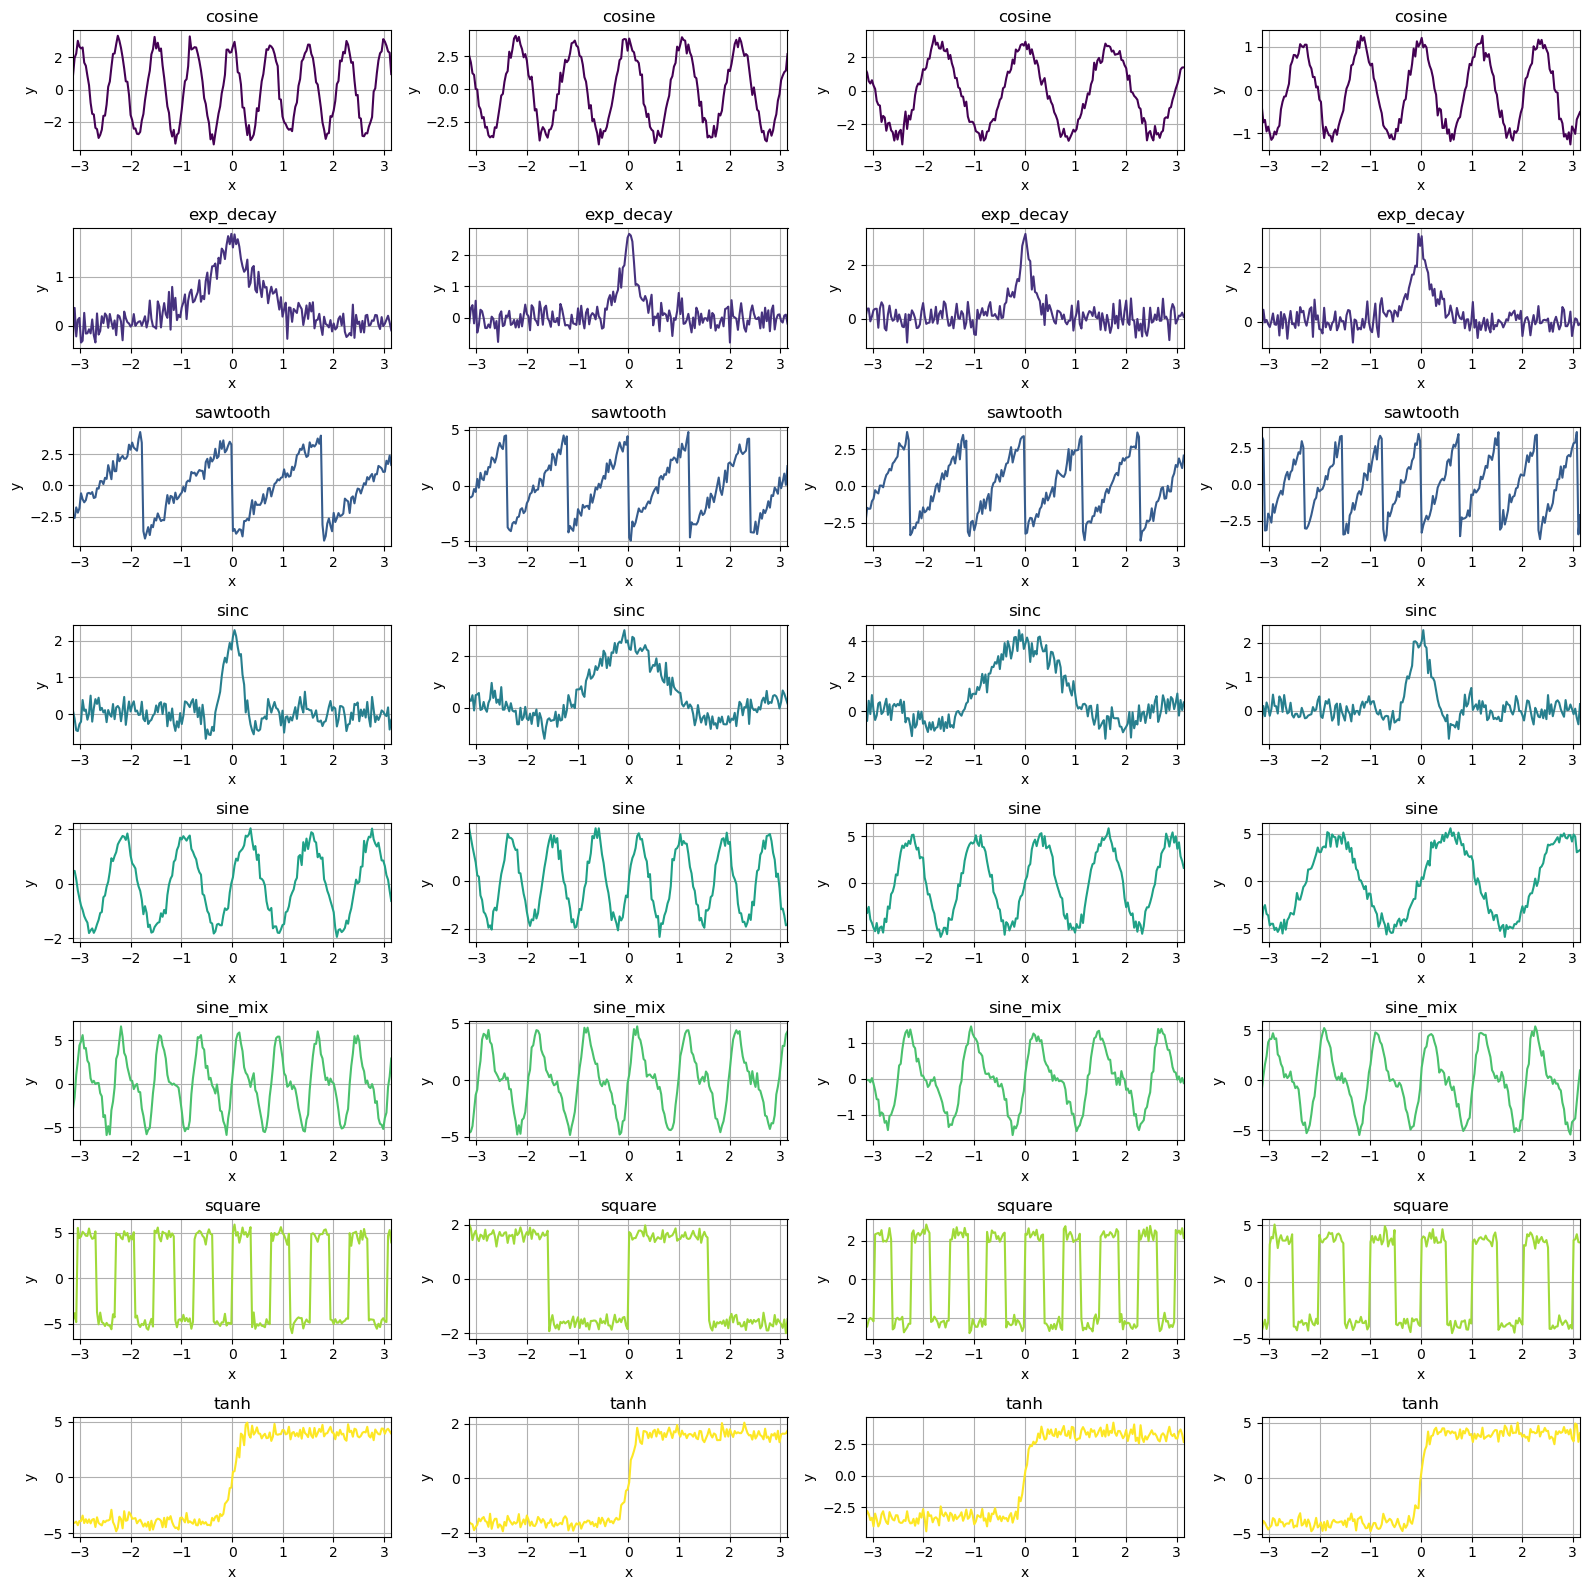

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sample_curves(curves, labels):
    # Get unique function types (labels)
    unique_labels = sorted(set(labels))
    n_types = len(unique_labels)
    cols = 4  # Four samples per type.
    rows = n_types  # One type per row.
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2 * rows))
    
    # Ensure axes is 2D even if there's only one row.
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
    
    # Loop through each unique label (each row is a type)
    for i, label in enumerate(unique_labels):
        # Get indices of curves corresponding to the current label.
        indices = [idx for idx, l in enumerate(labels) if l == label]
        
        # Plot up to four sample signals for this label.
        for j in range(cols):
            ax = axes[i, j]
            if j < len(indices):
                x, y = curves[indices[j]]
                ax.plot(x, y, label=label, color='lightgreen')
                ax.set_title(label)
                ax.set_xlim(-np.pi, np.pi)
                ax.grid(True)
                ax.set_xlabel("x")
                ax.set_ylabel("y")
            else:
                # Remove subplot if there are fewer than four signals.
                fig.delaxes(ax)
    
    plt.tight_layout()
    plt.show()

plot_sample_curves(curves, labels)


Notice the variability in amplitude (height) and frequency (number of cycles) - this is so that the model is exposed to a wide range of signals during training.

## Preparing the data

Now let us follow up with a few steps to prepare the data for training. Don't worry if you're not familiar with the details of these steps - the main focus here is to understand how regularisation can help improve performance.

Throughout this experiment we will be using the [PyTorch Lightning](https://www.pytorchlightning.ai/) library. PyTorch Lightning is a lightweight PyTorch wrapper that lets you train your models with less boilerplate code.

In [4]:
X = np.array([y for (_, y) in curves])
# For PyTorch Conv1d, we need shape (n_samples, channels, sequence_length)
X = X[:, np.newaxis, :]  # add channel dimension

print("X shape:", X.shape)

X shape: (8000, 1, 200)


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(labels)
n_classes = len(le.classes_)

print("Classes:", le.classes_)

Classes: ['cosine' 'exp_decay' 'sawtooth' 'sinc' 'sine' 'sine_mix' 'square' 'tanh']


In [6]:
from torch.utils.data import Dataset
import torch

# Create a custom PyTorch dataset.
class CurvesDataset(Dataset):
    def __init__(self, X, y):
        # X: numpy array (n_samples, 1, num_points)
        # y: numpy array (n_samples,)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CurvesDataset(X, y_encoded)

print("Dataset size:", len(dataset))

Dataset size: 8000


In [7]:
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split

def split_dataset(dataset, train_ratio=0.8, batch_size=n_classes):
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    return train_loader, val_loader

train_loader, val_loader = split_dataset(dataset)

## Defining the model

We are now ready to define our classifier. We will use a simple CNN architecture to identify each signal according to its nature, and we will create a *regularised* and non-regularised version of the model to compare their performance for different levels of noise in the signal.

```{admonition} Convolutional Neural Networks
:class: tip, dropdown

Convolutional Neural Networks (CNNs) are a type of deep learning model that is particularly well-suited for image classification tasks. They are designed to automatically and adaptively learn spatial hierarchies of features from input data. CNNs are made up of layers that detect patterns in the input data, such as edges, shapes, and textures, and combine them to recognize more complex patterns like objects or scenes. In our case, we are using a CNN to classify signals based on their shape, which is not too dissimilar from classifying images based on their content - we are looking for patterns in the data that help us distinguish between different classes.
```

Regularisation improves a model's ability to generalise by preventing it from overfitting to noise and minor fluctuations in the training data, leading to better performance on unseen data. We will use a form of regularisation called [weight decay](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), which penalises large weights in the model. We will also use *dropout* to prevent the model from overfitting to the training data, and L1 regularisation in the `training_step` function to penalize large weights in the model.

We could spend a lot of time going through the details of hyperparameters, the loss function, and the optimizer, but for now, let's focus on the regularisation techniques we are using to improve the model's performance and the effect they have on its ability to generalise to unseen shapes of data.

We can summarise all these common techniques in a single diagram to help put things into perspective.

```{mermaid}
:align: center

graph TD
    M@{shape: lean-r, label: "Model"}
    L@{shape: rect, label: "Loss Function"}
    L1@{shape: dbl-circ, label: "L1 Regularisation"}
    L2@{shape: dbl-circ, label: "L2 Regularisation"}
    WD@{shape: dbl-circ, label: "Weight Decay"}
    D@{shape: rect, label: "Dropout"}
    
    M -- "trained via" --> L
    L -- "includes" --> L1
    L -- "includes" --> L2
    L1 -- "penalizes absolute weights" --> M
    L2 -- "penalizes squared weights" --> M
    WD -- "penalizes weights" --> M
    D -- "randomly deactivates neurons" --> M

style L1 fill:#ffcccc,stroke:#ff0000,stroke-dasharray:5,5
style L2 fill:#ffcccc,stroke:#ff0000,stroke-dasharray:5,5
style WD fill:#ffcccc,stroke:#ff0000,stroke-dasharray:5,5
style D fill:#ccffcc,stroke:#008000,stroke-dasharray:5,5

linkStyle 0 stroke:#1f77b4,stroke-width:2px
linkStyle 1 stroke:#2ca02c,stroke-dasharray:5,5,stroke-width:2px
linkStyle 2 stroke:#2ca02c,stroke-dasharray:5,5,stroke-width:2px
linkStyle 3 stroke:#d62728,stroke-dasharray:3,3,stroke-width:2px
linkStyle 4 stroke:#d62728,stroke-dasharray:3,3,stroke-width:2px
linkStyle 5 stroke:#ff7f0e,stroke-dasharray:5,5,stroke-width:2px
linkStyle 6 stroke:#9467bd,stroke-dasharray:5,5,stroke-width:2px
```

Here's the definition of our regularised CNN model.

In [8]:
import torch
from torch import nn
import torch.nn.functional as F
import pytorch_lightning as pl

out_channels = 16
kernel_size = 5
weight_decay = 1e-4
l1_lambda = 1e-4
dropout_rate = 0.075

class CurveClassifierWithRegularisation(pl.LightningModule):
    def __init__(self, n_classes, seq_length, weight_decay=weight_decay, dropout_rate=dropout_rate, l1_lambda=l1_lambda):
        super().__init__()
        self.save_hyperparameters()  # This saves n_classes, seq_length, weight_decay, dropout_rate, and l1_lambda.
        
        # First convolutional layer.
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=out_channels, kernel_size=kernel_size)
        # Second convolutional layer.
        self.conv2 = nn.Conv1d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size)
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Compute the flattened feature size after both conv layers.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_length)
            x = F.relu(self.conv1(dummy))
            x = self.pool(x)
            x = F.relu(self.conv2(x))
            x = self.pool(x)
            self.feature_size = x.numel()  # total number of features
        
        # Define a dropout layer.
        self.dropout = nn.Dropout(dropout_rate)
        # One fully-connected layer mapping to n_classes.
        self.fc = nn.Linear(self.feature_size, n_classes)
    
    def forward(self, x):
        # x shape: (batch, 1, seq_length)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        x = self.dropout(x)
        x = self.fc(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        # Calculate L1 regularisation: sum the absolute values of all parameters.
        l1_norm = sum(torch.sum(torch.abs(param)) for param in self.parameters())
        loss = loss + self.hparams.l1_lambda * l1_norm
        
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
    
    def configure_optimizers(self):
        # L2 weight decay is applied via the weight_decay parameter.
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=0.001,
            weight_decay=self.hparams.weight_decay
        )
        return optimizer

In [9]:
# Instantiate the model.
model = CurveClassifierWithRegularisation(
    n_classes=n_classes,
    seq_length=num_points
)
print(model)

CurveClassifierWithRegularisation(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(5,), stride=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.075, inplace=False)
  (fc): Linear(in_features=752, out_features=8, bias=True)
)


With the model defined, we can now train it on the synthetic data we generated earlier and check how well it performs against the validation set.

In [10]:
from pytorch_lightning.callbacks import EarlyStopping

# Define EarlyStopping callback.
early_stop_callback = EarlyStopping(
    monitor='val_loss',    # Monitor validation loss.
    min_delta=0.00,        # Minimum change in the monitored quantity to qualify as an improvement.
    patience=3,            # How many epochs to wait before stopping when no improvement.
    verbose=False,
    mode='min'             # We want to minimize validation loss.
)

max_epochs = 100

# Train the Model with PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=max_epochs,
    callbacks=[early_stop_callback],
    deterministic=True
)
trainer.fit(
    model,
    train_loader,
    val_loader
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type      | Params | Mode 
----------------------------------------------
0 | conv1   | Conv1d    | 96     | train
1 | conv2   | Conv1d    | 1.3 K  | train
2 | pool    | MaxPool1d | 0      | train
3 | dropout | Dropout   | 0      | train
4 | fc      | Linear    | 6.0 K  | train
----------------------------------------------
7.4 K     Trainable params
0         Non-trainable params
7.4 K     Total params
0.030     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/NLeitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/NLeitao/miniconda3/envs/ml-env-latest/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [11]:
val_loss = trainer.callback_metrics.get("val_loss")
val_acc = trainer.callback_metrics.get("val_acc")
print("Regularised Model:")
print(f"\tValidation Loss: {val_loss}, Validation Accuracy: {val_acc}")

Regularised Model:
	Validation Loss: 0.0024467515759170055, Validation Accuracy: 1.0


A validation accuracy of 1.0 (100%) means that the model is able to classify all the signals in the validation set correctly. This is a good sign that the model has learned to generalise well to unseen data.

Let us now define a similar model without regularisation and train it on the same data to compare its performance against the regularised model.

In [12]:
import torch
from torch import nn
import torch.nn.functional as F
import pytorch_lightning as pl

class CurveClassifierWithoutRegularisation(pl.LightningModule):
    def __init__(self, n_classes, seq_length):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=out_channels, kernel_size=kernel_size)
        self.conv2 = nn.Conv1d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size)
        self.pool = nn.MaxPool1d(kernel_size=2)
        
        # Compute the flattened feature size after both conv layers.
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_length)
            x = F.relu(self.conv1(dummy))
            x = self.pool(x)
            x = F.relu(self.conv2(x))
            x = self.pool(x)
            self.feature_size = x.numel()  # total number of features
        
        # Remove dropout (regularisation) completely.
        self.fc = nn.Linear(self.feature_size, n_classes)
    
    def forward(self, x):
        # x shape: (batch, 1, seq_length)
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, start_dim=1)
        # No dropout here
        x = self.fc(x)
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
    
    def configure_optimizers(self):
        # No weight decay is used.
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        return optimizer

In [13]:
model_without_regularisation = CurveClassifierWithoutRegularisation(
    n_classes=n_classes,
    seq_length=num_points
)
print(model_without_regularisation)

CurveClassifierWithoutRegularisation(
  (conv1): Conv1d(1, 16, kernel_size=(5,), stride=(1,))
  (conv2): Conv1d(16, 16, kernel_size=(5,), stride=(1,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=752, out_features=8, bias=True)
)


In [ ]:
# Reinstantiate the early stopping callback.
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00,
    patience=3,
    verbose=False,
    mode='min'
)

trainer = pl.Trainer(
    max_epochs=max_epochs,
    callbacks=[early_stop_callback],
    deterministic=True
)
trainer.fit(
    model_without_regularisation,
    train_loader,
    val_loader
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | conv1 | Conv1d    | 96     | train
1 | conv2 | Conv1d    | 1.3 K  | train
2 | pool  | MaxPool1d | 0      | train
3 | fc    | Linear    | 6.0 K  | train
--------------------------------------------
7.4 K     Trainable params
0         Non-trainable params
7.4 K     Total params
0.030     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
val_loss = trainer.callback_metrics.get("val_loss")
val_acc = trainer.callback_metrics.get("val_acc")
print("Regularised Model:")
print(f"\tValidation Loss: {val_loss}, Validation Accuracy: {val_acc}")

Regularised Model:
	Validation Loss: 0.00040306628216058016, Validation Accuracy: 1.0


The non-regularised model also achieves 100% validation accuracy but has a lower validation loss compared to the regularised model. This suggests potential overfitting, which may hinder its ability to generalise to new data. We can test this thesis when we apply the models to a fresh test set.

## Applying the models to noisy signals

To demonstrate the generalisation effects of regularisation, let us test our classifiers against increasing levels of noise in the signals, and also against a set which has been generated with a different random seed (i.e., an entirely different set of frequencies, amplitudes, etc.).

To show how noise can quickly "drown" the underlying signal, let us look at what our waveforms look like when a noise factor os 0.8 is used (versus 0.1 which we used for training) during generation.

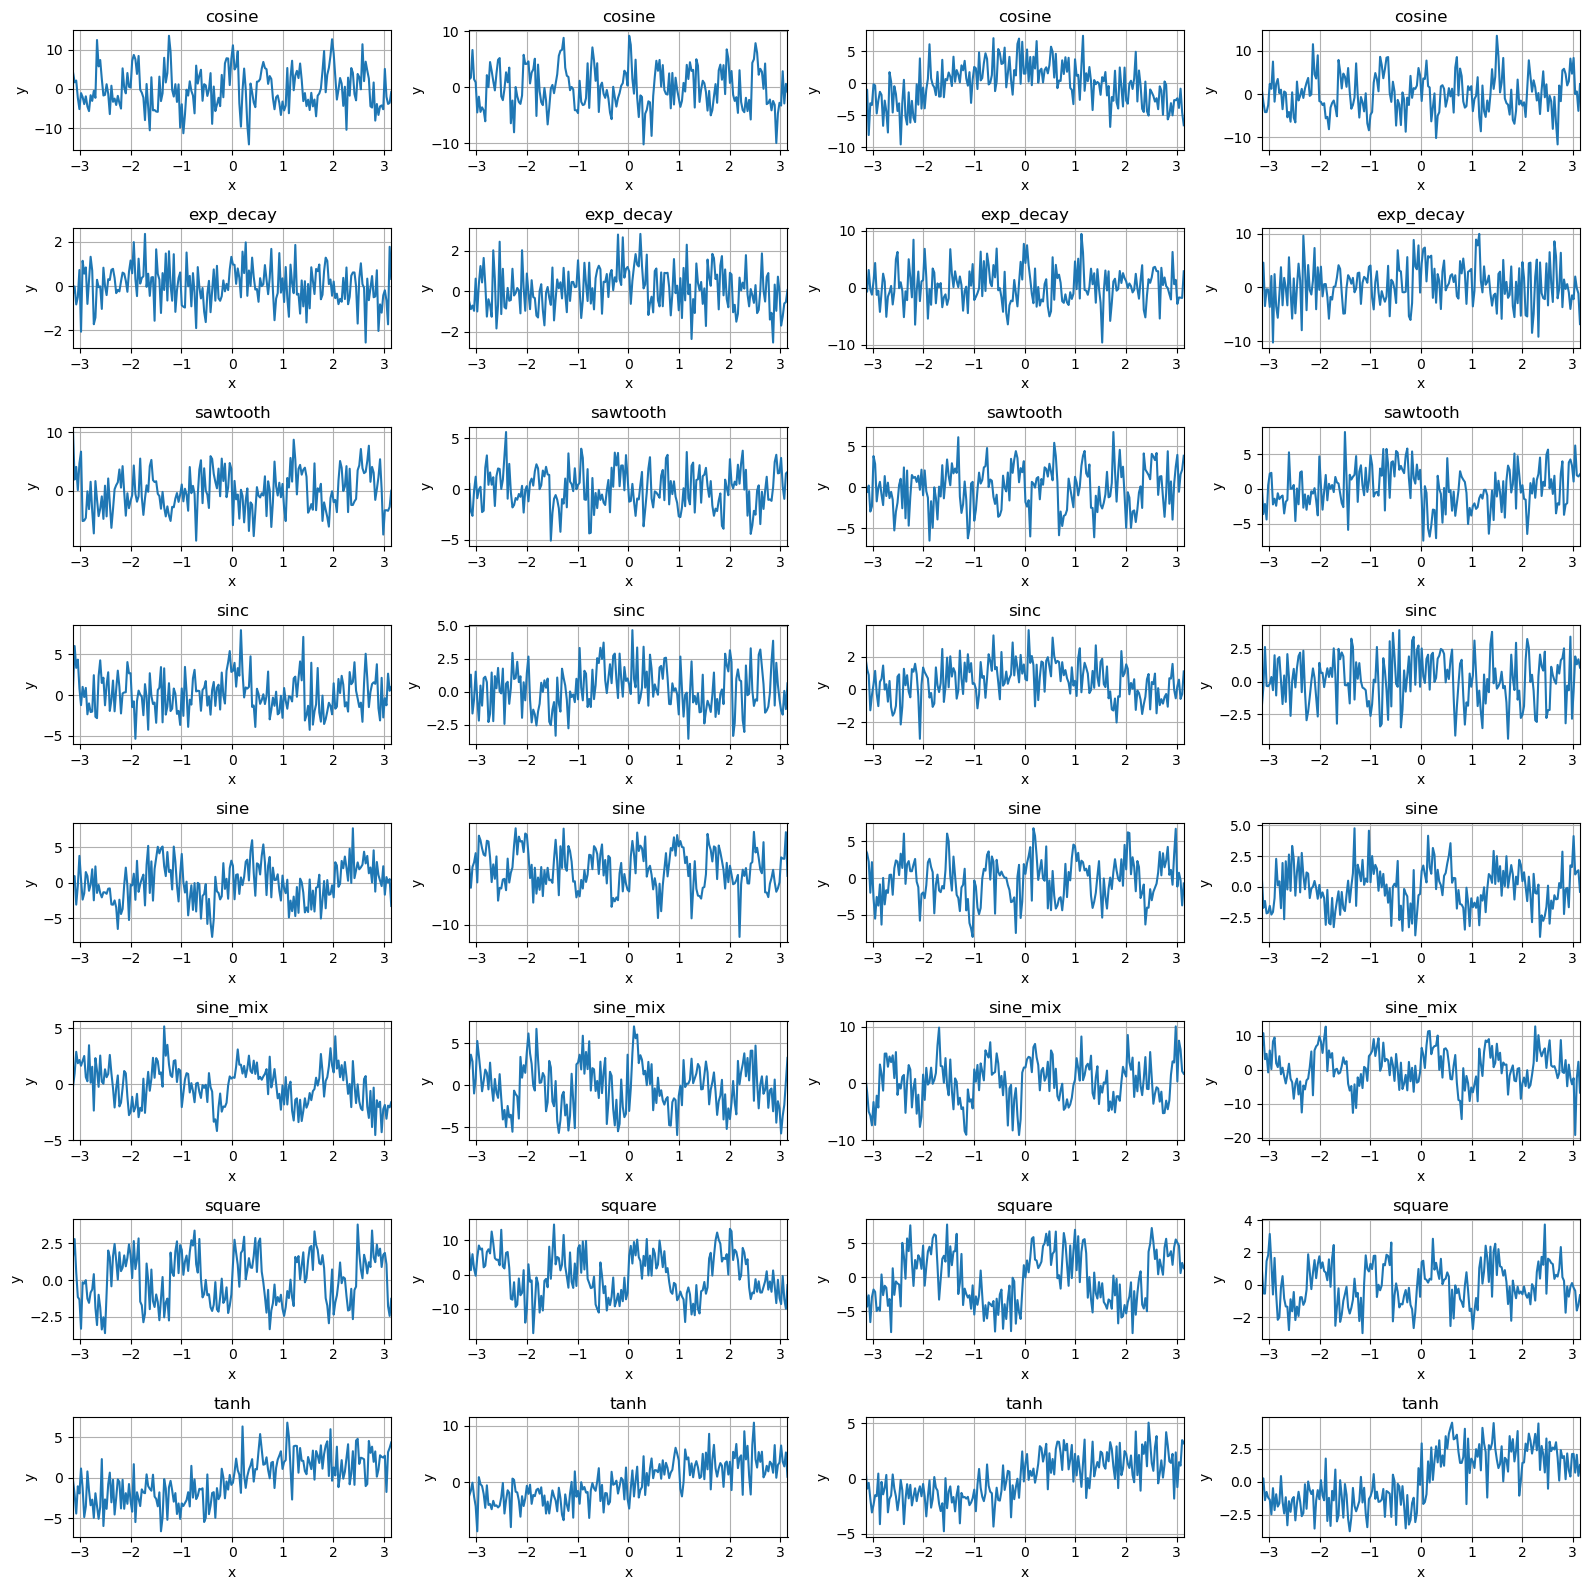

In [ ]:
curves, labels = generate_curves(
    8*4,
    noise_factor=0.8,
    num_points=num_points
)
plot_sample_curves(curves, labels)

As it is pretty obvious, noise can "drown" the signal, making it harder for classification to happen correctly.

A robust way to evaluate the performance of our models is to test them against increasing levels of noise in the signals, and compare the performance of each - it will show how capable each is to discern the true signal from the noise. Regularisation *should* help in better generalisation, and we can verify if this is indeed the case.

In [ ]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            predictions = logits.argmax(dim=1)
            correct += (predictions == y).sum().item()
            total += y.size(0)
    return correct / total

# Define noise levels from 0 to 1 with an increment of 0.1.
noise_levels = np.arange(0, 1, 0.05)
acc_regularised = []
acc_non_regularised = []

# Loop over noise levels.
random_seed = 1
for noise in noise_levels:
    # Generate curves with the current noise factor.
    curves, labels = generate_curves(1000, noise_factor=noise, random_seed=random_seed, num_points=num_points)
    random_seed += 1

    X = np.array([y for (_, y) in curves])
    X = X[:, np.newaxis, :]  # reshape to (n_samples, channels, sequence_length)
    # Encode labels.
    y_encoded = le.transform(labels)
    
    dataset = CurvesDataset(X, y_encoded)
    _, loader = split_dataset(train_ratio=0.001, dataset=dataset)
    
    # Evaluate both models on the validation loader.
    reg_acc = evaluate_model(model, loader)
    non_reg_acc = evaluate_model(model_without_regularisation, loader)
    
    acc_regularised.append(reg_acc)
    acc_non_regularised.append(non_reg_acc)

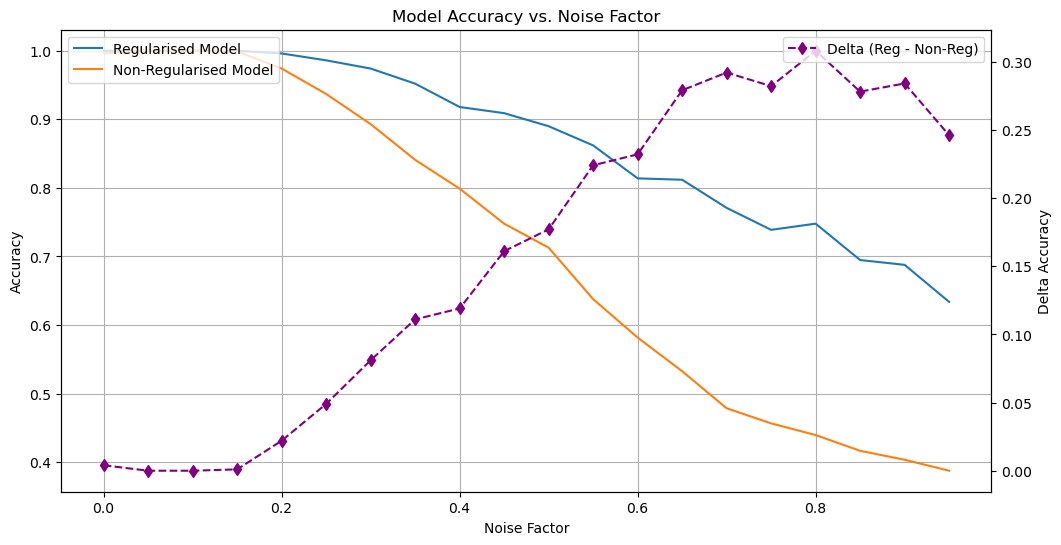

In [ ]:
delta = np.array(acc_regularised) - np.array(acc_non_regularised)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the accuracies on the primary y-axis.
ax1.plot(noise_levels, acc_regularised, label='Regularised Model')
ax1.plot(noise_levels, acc_non_regularised, label='Non-Regularised Model')
ax1.set_xlabel("Noise Factor")
ax1.set_ylabel("Accuracy")
ax1.set_title("Model Accuracy vs. Noise Factor")
ax1.grid(True)
ax1.legend(loc='upper left')

# Create a secondary y-axis to plot the delta.
ax2 = ax1.twinx()
ax2.plot(noise_levels, delta, color='purple', linestyle='--', marker="d", label='Delta (Reg - Non-Reg)')
ax2.set_ylabel("Delta Accuracy")
ax2.legend(loc='upper right')

plt.show()


This chart shows the performance of the regularised and non-regularised models - up to a noise level of 0.2, both perform pretty much comparably. However, as the noise level increases, the regularised model performs much better. This is a clear indication that it is helping and that the model can separate the true signal from the noise. Comparing the two, at a noise level of 0.8, the regularised model still has a an accuracy of ~75%, while the non-regularised one has dropped to ~45%!

The striking divergence in performance as noise increases clearly illustrates the protective effect of regularisation. By constraining the model from overfitting to random fluctuations, regularisation ensures that it captures the essential patterns in the data. This stability becomes increasingly critical as noise levels rise, reinforcing its capacity to isolate the true signal even in challenging conditions. Such robustness is exactly what makes these techniques invaluable when dealing with complex, "dirty" real-world data.

## Final remarks

Hopefully this example has given you a good intuition about how regularisation can help improve the performance of your models, especially when dealing with noisy or complex data. It is a powerful tool in any practicioners' toolbox, and it can help you build applications that are more robust, generalise better to unseen data, and are less likely to overfit to the training data.